# $\mathrm{K}_{\mathrm{V}}2.1$ F412L S6-neighborhood distance analysis

Default ensemble subset: **allOk3 + structural/interface QC** (`all_ok_3_structural_interface_qc`; corrected 3 Å convergence, G377 tetramer-integrity filtering, and a 27 Å pore–VSD interface cutoff).
The same residue pairs are used for four complementary comparisons: WT versus F412L within each protocol, and vanilla versus masked within each construct. The 8SD3 WT and 8SDA L403A structures are overlaid as experimental state references because L403A and F412L were proposed to perturb related S6 rearrangements. These references test whether F412L samples an L403A-like direction; 8SDA is not a mutation-matched F412L structure.


## Comparison design

The analysis separates two effects that should not be conflated. WT and F412L
are compared within vanilla and masked protocols to estimate the mutation
effect, while vanilla and masked ensembles are compared within WT and F412L to
estimate the masking effect. The same ranked Cα-distance panel is retained in
all four comparisons, and 8SD3 WT and 8SDA L403A values provide fixed
experimental state references.

### WT–F412L hydrophobic-nexus comparison

The image below loads the current publication-resolution export, including the WT and F412L vanilla and masked ensembles and the Kv2.1 experimental references.

![WT versus F412L hydrophobic-nexus geometry](dataRMSD/analysis/nexus/figures/f412l_nexus_geometry_vs_experiment.png)


### F412L-only hydrophobic-nexus comparison

This focused version removes the WT prediction distributions. Each violin places F412L vanilla on the left and F412L masked on the right. The 8SD3 WT and 8SDA L403A measurements remain as structural references rather than mutation-matched observations.

![F412L-only hydrophobic-nexus geometry](dataRMSD/analysis/nexus/figures/f412l_only_nexus_geometry_vs_experiment.png)


In [1]:
from pathlib import Path
import sys
import pandas as pd
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
from shared.mutation_site_analysis import nearby_distance_columns, rank_nearby_shifts, top_aliases
import importlib, shared.dataset_selection as shared_dataset_selection
importlib.reload(shared_dataset_selection)
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
from shared.plotting import KV21_PALETTE, apply_kv21_style, experimental_reference_style, plot_split_ensemble_with_experimentals, plot_protocol_split_with_experimentals
apply_kv21_style()


In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'kv21'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Kv21_F412L_mutationSite_analysis')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/kv21/Kv21_F412L_mutationSite_analysis')

In [3]:
DATASET_SELECTION = 'all_ok_3_structural_interface_alignment_qc'  # Final convergence, tetramer, interface, and v2 alignment QC.
data = repo_root / 'kv21' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_vanillaAF2_distances_all.csv', 'Kv21', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_maskedAF2_distances_all.csv', 'Kv21', 'WT', 'masked'),
    'F412L vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_f412l_vanillaAF2_distances_all.csv', 'Kv21', 'F412L', 'vanilla'),
    'F412L masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_f412l_maskedAF2_distances_all.csv', 'Kv21', 'F412L', 'masked'),
}
DATASET_PATHS
wt_van = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
wt_mask = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
mut_van = load_selected_distance_csv('F412L vanilla', DATASET_PATHS['F412L vanilla'], DATASET_SELECTION)
mut_mask = load_selected_distance_csv('F412L masked', DATASET_PATHS['F412L masked'], DATASET_SELECTION)


WT vanilla: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv
WT masked: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv


F412L vanilla: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_f412l_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv
F412L masked: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_f412l_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv


## S6-neighborhood distributions

Candidate coordinates are ranked by the largest absolute WT-to-F412L median
shift observed in either protocol. Split violins show the complete retained
ensemble rather than only summary statistics. The experimental 8SDA points test
whether F412L samples an L403A-like S6 direction; they are not a
mutation-matched F412L validation structure.

,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A,protocol
25,shortest_ILE407A-ILE409C,18.80,17.90,-0.90,0.90,vanilla
73,shortest_ILE407B-ILE409D,18.80,17.90,-0.90,0.90,vanilla
72,shortest_ILE407B-PRO408D,12.90,12.00,-0.90,0.90,vanilla
24,shortest_ILE407A-PRO408C,12.90,12.00,-0.90,0.90,vanilla
120,CA_CA_A_ILE407_CA-C_PRO408_CA,15.18,14.32,-0.86,0.86,vanilla
168,CA_CA_B_ILE407_CA-D_PRO408_CA,15.17,14.31,-0.86,0.86,vanilla
121,CA_CA_A_ILE407_CA-C_ILE409_CA,18.82,17.98,-0.84,0.84,vanilla
169,CA_CA_B_ILE407_CA-D_ILE409_CA,18.81,17.97,-0.84,0.84,vanilla
70,shortest_LEU405B-PRO408D,17.50,16.70,-0.80,0.80,vanilla
79,shortest_VAL411B-ILE409D,16.70,15.90,-0.80,0.80,vanilla


,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A,protocol
207,CA_CA_A_LEU405_CA-D_VAL411_CA,15.810,6.09,-9.720,9.720,masked
189,CA_CA_C_VAL411_CA-D_LEU405_CA,15.125,6.04,-9.085,9.085,masked
39,shortest_LEU405A-ILE409D,20.100,11.20,-8.900,8.900,masked
109,CA_CA_A_VAL411_CA-B_LEU405_CA,14.310,6.02,-8.290,8.290,masked
95,shortest_VAL411C-ILE409D,15.500,7.70,-7.800,7.800,masked
15,shortest_VAL411A-ILE409B,14.450,7.70,-6.750,6.750,masked
194,shortest_LEU405A-VAL411D,13.100,6.40,-6.700,6.700,masked
94,shortest_VAL411C-PRO408D,10.800,4.30,-6.500,6.500,masked
93,shortest_VAL411C-LEU405D,12.900,6.40,-6.500,6.500,masked
135,CA_CA_A_LEU405_CA-D_ILE409_CA,16.910,10.95,-5.960,5.960,masked


Experimental matches: 8SD3=12/12, 8SDA=12/12


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


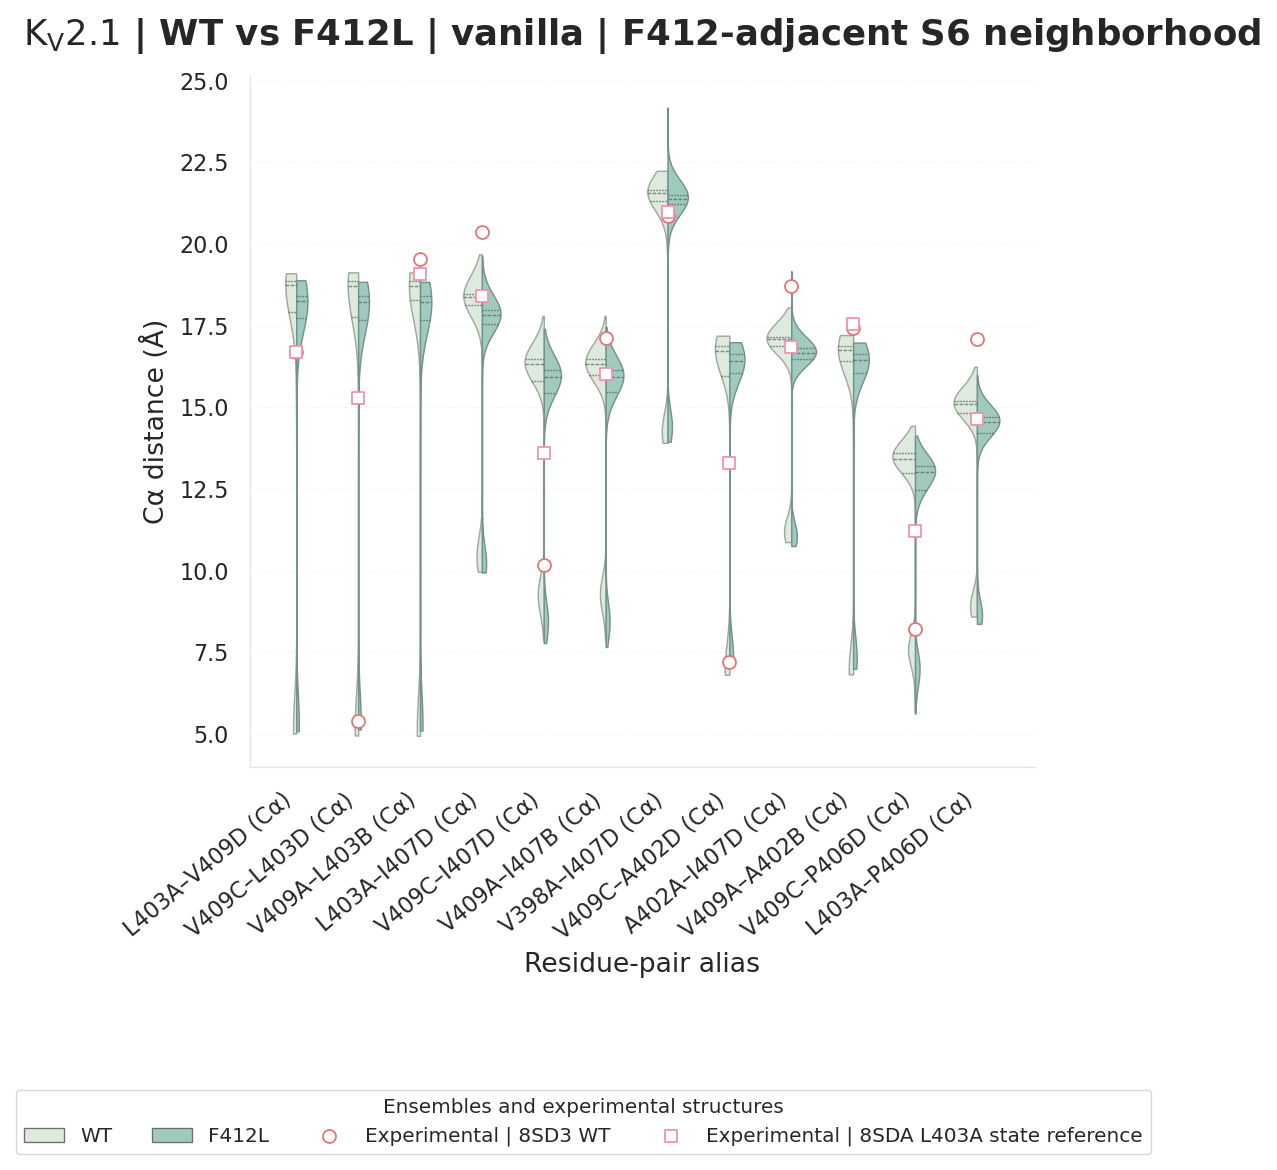

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


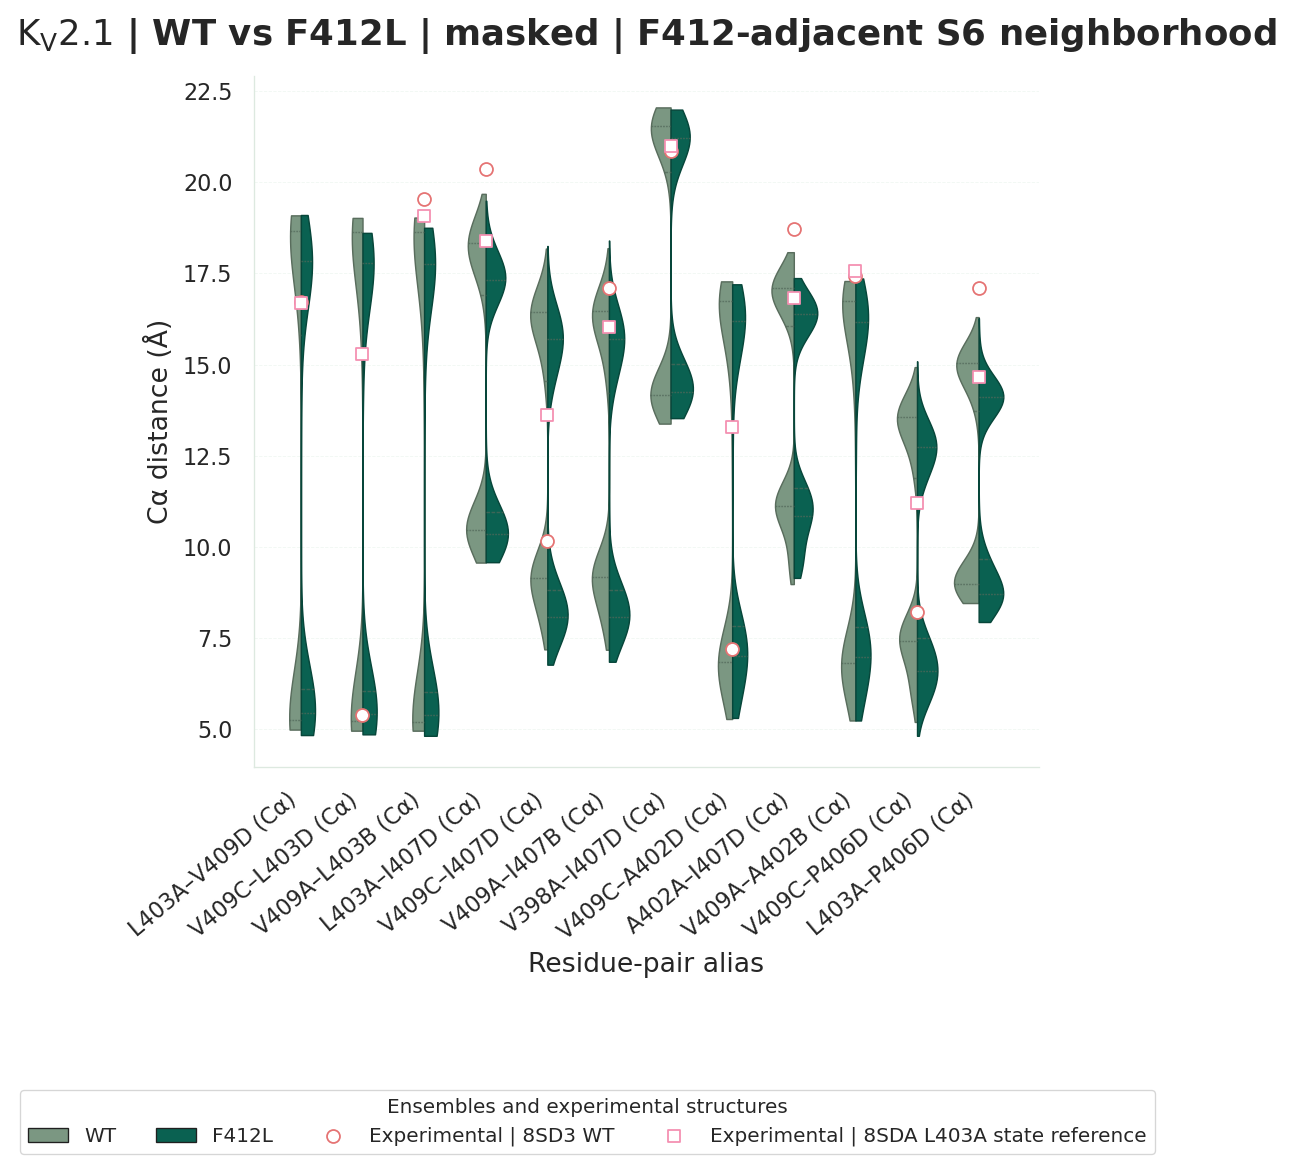

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


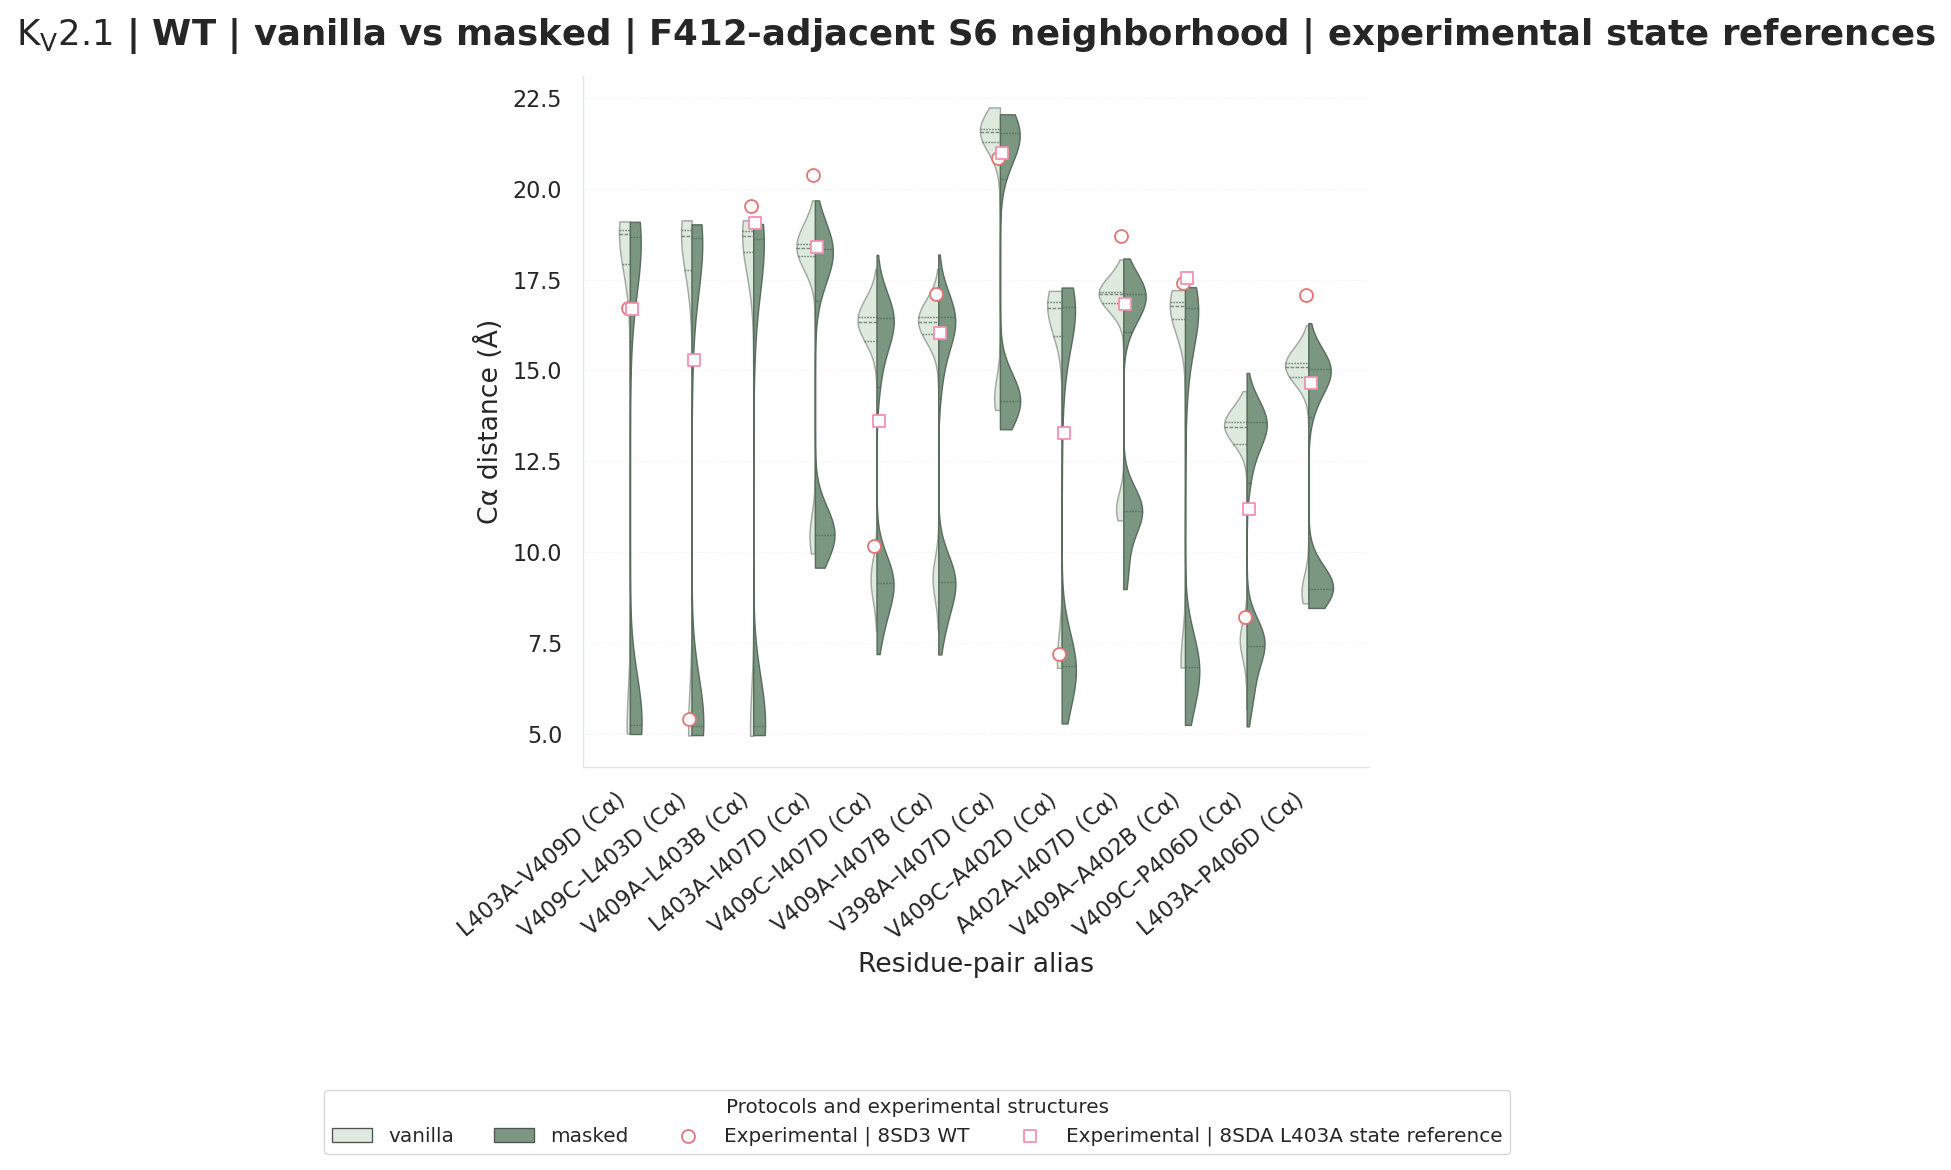

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


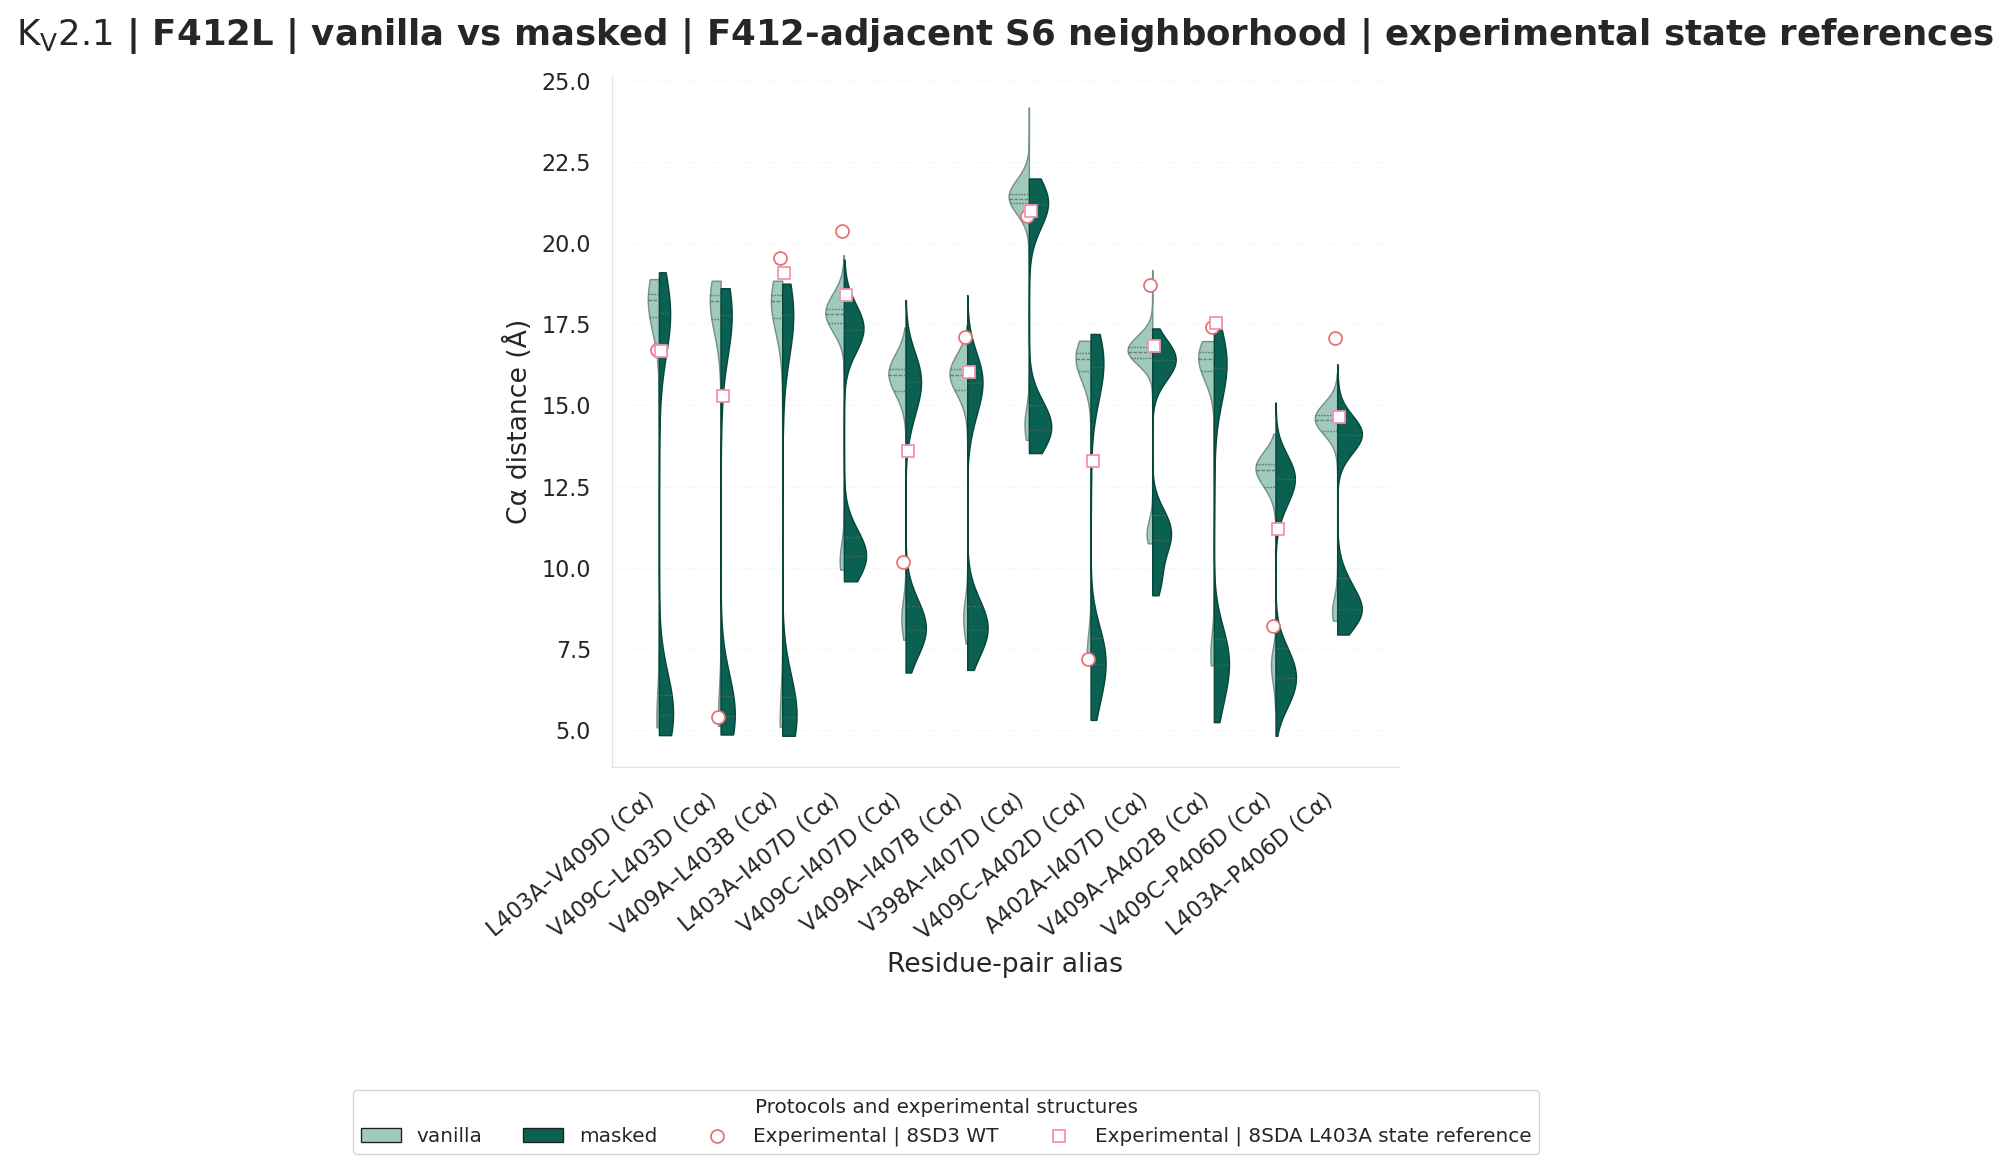

,Protocol,Partner,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT contact ≤4 Å,Mutant contact ≤4 Å,Mutant overlap <2 Å,n
14,vanilla,LEU405D,5.5,4.1,-1.4,0.000,0.435,0.000,4407
23,masked,LEU405B,14.5,4.5,-10.0,0.013,0.380,0.030,3578
16,vanilla,ILE409D,5.0,4.6,-0.4,0.007,0.181,0.000,4407
25,masked,ILE409B,19.8,6.2,-13.6,0.083,0.143,0.000,3578
35,masked,LEU405D,15.5,22.6,7.1,0.011,0.143,0.008,3578
40,masked,LEU318A,5.8,4.9,-0.9,0.141,0.125,0.000,3578
37,masked,ILE409D,21.3,21.4,0.1,0.059,0.100,0.000,3578
2,vanilla,LEU405B,25.7,23.2,-2.5,0.000,0.095,0.000,4407
4,vanilla,ILE409B,26.0,23.3,-2.7,0.002,0.062,0.000,4407
10,vanilla,ILE409C,21.2,19.6,-1.6,0.001,0.020,0.000,4407


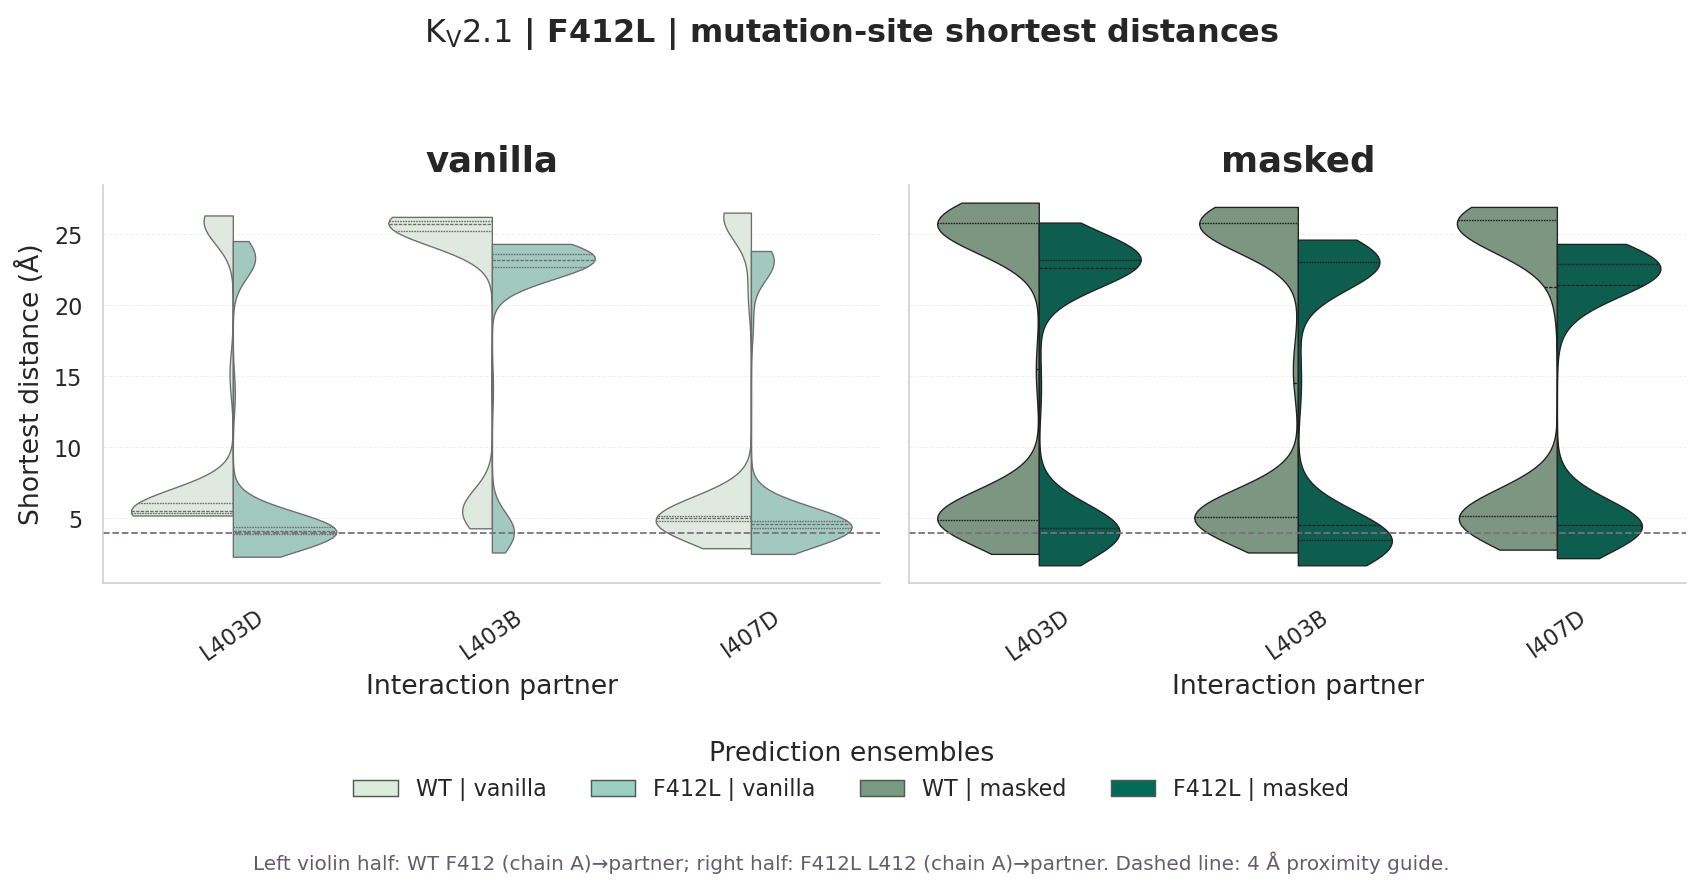

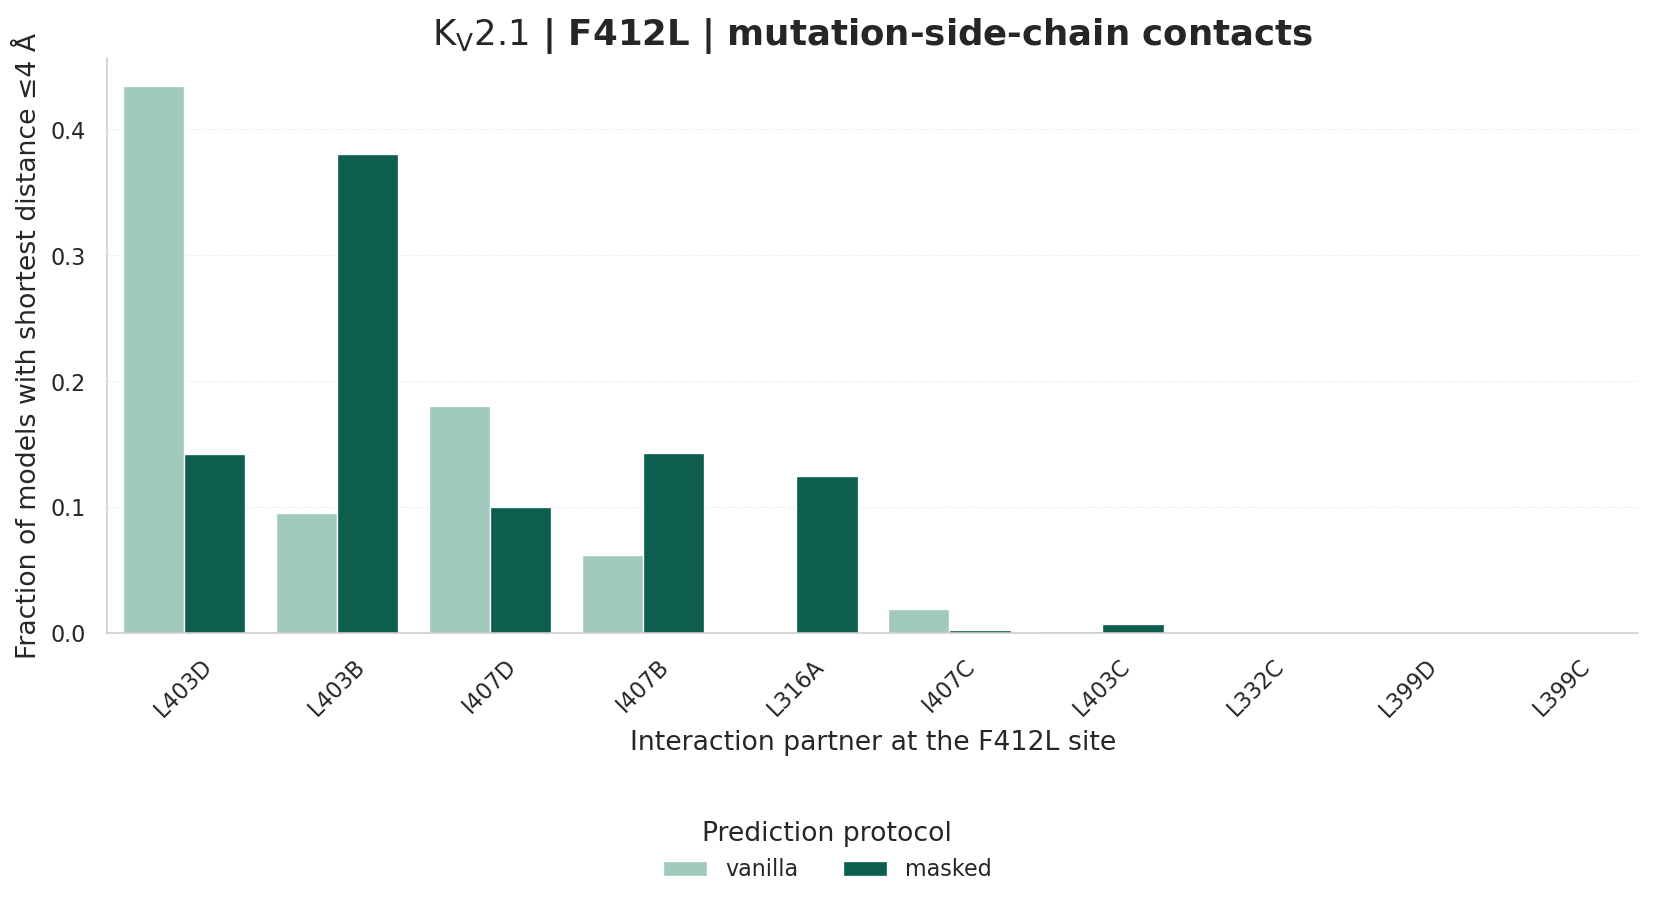

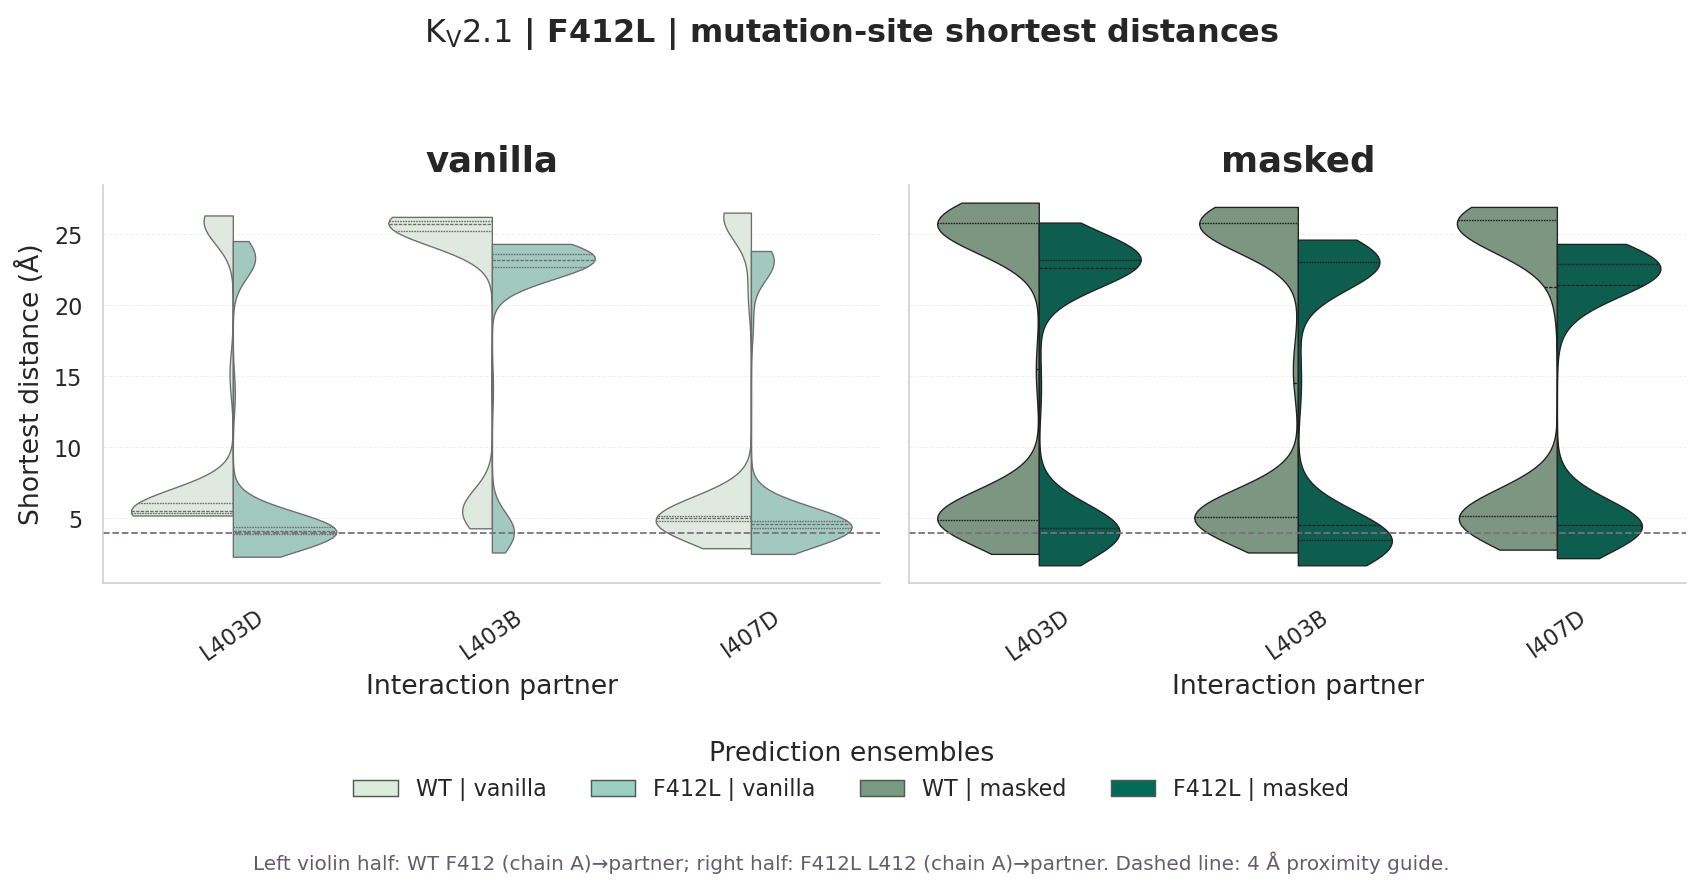

In [4]:
import importlib
from shared.structure_distances import experimental_distances_for_aliases as experimental_for_aliases

# Select one compact set of F412-adjacent distances for every panel. Ranking by the
# largest shift seen in either protocol avoids changing the x axis between comparisons.
vanilla_shifts = rank_nearby_shifts(wt_van, mut_van, nearby_distance_columns(wt_van, 412))
masked_shifts = rank_nearby_shifts(wt_mask, mut_mask, nearby_distance_columns(wt_mask, 412))
combined_shifts = pd.concat([vanilla_shifts, masked_shifts], ignore_index=True)
combined_shifts = combined_shifts[combined_shifts['distance'].str.startswith('CA_CA_')]
combined_shifts = combined_shifts.sort_values('abs_shift_A', ascending=False).drop_duplicates('distance')
aliases = top_aliases(combined_shifts, n=12, residue_number_offset=-2)
display(vanilla_shifts.head(12).assign(protocol='vanilla'))
display(masked_shifts.head(12).assign(protocol='masked'))

# Calculate the matching Cα distances directly from the experimental coordinates.
# Visible aliases already use the experimental/paper numbering (model numbering − 2).
import math, re


exp_wt, missing_wt = experimental_for_aliases(aliases, repo_root/'kv21'/'experimental'/'8SD3.pdb')
exp_l403a, missing_l403a = experimental_for_aliases(aliases, repo_root/'kv21'/'experimental'/'8SDA.pdb')
print(f'Experimental matches: 8SD3={len(exp_wt)}/{len(aliases)}, 8SDA={len(exp_l403a)}/{len(aliases)}')
if missing_wt or missing_l403a:
    print('Unresolved aliases:', sorted(set(missing_wt + missing_l403a)))
experimental_distances = [exp_wt, exp_l403a]
experimental_labels = ['Experimental | 8SD3 WT', 'Experimental | 8SDA L403A state reference']
experimental_colors = [experimental_reference_style(reference)['color'] for reference in ('8SD3', '8SDA')]
region = 'F412-adjacent S6 neighborhood'

# Mutation effect within each prediction protocol.
plot_split_ensemble_with_experimentals(wt_van, mut_van, aliases, 'F412L', 'vanilla', region, experimental_distances, experimental_labels, experimental_colors)
plot_split_ensemble_with_experimentals(wt_mask, mut_mask, aliases, 'F412L', 'masked', region, experimental_distances, experimental_labels, experimental_colors)

# Masking effect within each sequence background.
plot_protocol_split_with_experimentals(wt_van, wt_mask, aliases, 'Kv2.1 | WT | vanilla vs masked | F412-adjacent S6 neighborhood | experimental state references', [KV21_PALETTE['WT_VAN'], KV21_PALETTE['WT_HM']], experimental_distances, experimental_labels, experimental_colors)
plot_protocol_split_with_experimentals(mut_van, mut_mask, aliases, 'Kv2.1 | F412L | vanilla vs masked | F412-adjacent S6 neighborhood | experimental state references', [KV21_PALETTE['F412L_VAN'], KV21_PALETTE['F412L_HM']], experimental_distances, experimental_labels, experimental_colors)

## Contacts altered by F412L (model/CSV F414L)
import shared.plotting as shared_plotting
importlib.reload(shared_plotting)
import shared.mutation_contact_analysis as mutation_contact_analysis
importlib.reload(mutation_contact_analysis)
from shared.mutation_contact_analysis import plot_mutation_contacts, plot_selected_contact_distributions
f412l_contact_table, _ = plot_mutation_contacts(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'PHE414A', 'LEU414A', 'F412L',
    {'vanilla': KV21_PALETTE['F412L_VAN'], 'masked': KV21_PALETTE['F412L_HM']}, channel='Kv2.1',
)
display(f412l_contact_table.head(15).round(3))
f412l_top_partners = list(dict.fromkeys(f412l_contact_table['Partner']))[:3]
f412l_contact_distributions, f412l_contact_figure = plot_selected_contact_distributions(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'PHE414A', 'LEU414A', 'F412L', f412l_top_partners,
    {'vanilla': (KV21_PALETTE['WT_VAN'], KV21_PALETTE['F412L_VAN']), 'masked': (KV21_PALETTE['WT_HM'], KV21_PALETTE['F412L_HM'])}, channel='Kv2.1',
    show_overlap_region=False,
)
display(f412l_contact_figure)
contact_figure_dir = repo_root / 'kv21' / 'dataDistances' / 'analysis' / 'figures'
contact_figure_dir.mkdir(parents=True, exist_ok=True)
f412l_contact_figure.savefig(
    contact_figure_dir / 'f412l_mutation_site_shortest_distances.png',
    dpi=400, bbox_inches='tight',
)


## Hydrophobic coupling nexus: experimental benchmark

F412 sits at the intracellular end of S6, where it couples to L316 in the S4–S5 linker and to L329 and L403 in the neighboring pore-forming subunit. This compact hydrophobic network links voltage-sensor movement to the S6 gate. The F412L mutant was functionally severe, but the corresponding cryo-EM reconstruction could not be resolved. The L403A structure (8SDA) therefore provides the closest experimental view of how weakening this nexus can promote inactivation.

The experimental comparison is asymmetric. In 8SD3, all three contacts are close to 3.8–3.9 Å in every subunit. In 8SDA, the same-chain F412–L316 contact remains compact, whereas the nearest intersubunit F412–L329 and F412–L403 contacts spread over approximately 3.5–7.3 Å. Thus, the structural signature is not uniform expansion of the entire nexus. It is retention of the S4–S5-linker contact together with asymmetric loss or redistribution of the neighboring S5/S6 contacts.

Two complementary tests are used below. First, for each model and region,

\[
\Delta_{\mathrm{reference}} = \mathrm{RMSD}_{8\mathrm{SDA}}-\mathrm{RMSD}_{8\mathrm{SD3}}.
\]

Negative values identify models locally closer to the L403A structure; positive values identify models closer to WT. Second, shortest heavy-atom distances test whether the three physical contacts are retained. In the nexus-distance figure, the left violin half represents WT F412 and the right half represents F412L L412, with vanilla and masked ensembles in separate panels. Cross-chain labels are not assumed to correspond between 8SD3, 8SDA, and AlphaFold models; the closest available partner in each tetramer is used. This avoids converting a cyclic chain-label change into a false contact loss.

The representative-model score is the mean Cα RMSD to 8SDA across the hydrophobic nexus, L403 region, and F412 region after stable-core alignment. It is useful for choosing structures to inspect, but it is not an all-atom side-chain RMSD and should not be interpreted as proof that every rotamer is correct.

Kv2.1 structural RMSD QC: 49,314 rows → 48,538 after tetramer/interface QC → 48,538 after excluding 0 separated alignment-failure trajectories (stable-core cutoff 4 Å)


,sequence_condition,protocol,Region,n,median_delta_A,mean_delta_A,fraction_L403A_like
0,f412l,masked,F412 region,3578,0.175,0.104,0.417
1,f412l,masked,Hydrophobic nexus,3578,0.383,0.280,0.314
2,f412l,masked,L403 region,3578,0.471,0.428,0.204
3,f412l,vanilla,F412 region,4407,0.376,0.306,0.216
4,f412l,vanilla,Hydrophobic nexus,4407,0.528,0.490,0.030
5,f412l,vanilla,L403 region,4407,0.899,0.854,0.001
6,l403a,masked,F412 region,3693,1.116,0.880,0.130
7,l403a,masked,Hydrophobic nexus,3693,1.005,0.833,0.109
8,l403a,masked,L403 region,3693,1.441,1.235,0.076
9,l403a,vanilla,F412 region,4371,1.218,1.165,0.020


,Sequence,Protocol,Contact,n,median_nearest_A,q25_nearest_A,q75_nearest_A,fraction_models_with_contact,fraction_probable_overlap,number_of_available_pairs,coverage_note
0,F412L,Masked,L316 (S4–S5 linker),3578,4.8,4.2,5.2,0.195,0.000,4,4 same-chain distances available
1,F412L,Masked,L329 (neighboring S5),3578,6.6,6.1,8.0,0.000,0.000,6,6 directed cross-chain distances available; le...
2,F412L,Masked,L403 (neighboring S6),3578,3.9,2.7,4.3,0.580,0.047,12,12 directed cross-chain distances available
3,F412L,Vanilla,L316 (S4–S5 linker),4407,4.9,4.7,5.1,0.000,0.000,4,4 same-chain distances available
4,F412L,Vanilla,L329 (neighboring S5),4407,6.3,6.1,6.7,0.000,0.000,6,6 directed cross-chain distances available; le...
5,F412L,Vanilla,L403 (neighboring S6),4407,4.0,3.9,4.2,0.571,0.000,12,12 directed cross-chain distances available
6,WT,Masked,L316 (S4–S5 linker),3658,5.7,5.4,5.8,0.155,0.000,4,4 same-chain distances available
7,WT,Masked,L329 (neighboring S5),3658,4.1,3.9,4.5,0.468,0.000,6,6 directed cross-chain distances available; le...
8,WT,Masked,L403 (neighboring S6),3658,5.0,4.8,5.2,0.028,0.000,12,12 directed cross-chain distances available
9,WT,Vanilla,L316 (S4–S5 linker),4562,5.9,5.8,6.0,0.004,0.000,4,4 same-chain distances available


,Reference,Contact,Source chain,Partner chain,Shortest heavy-atom distance (Å)
0,8SD3 | WT,L316 (S4–S5 linker),A,A,3.892
1,8SD3 | WT,L316 (S4–S5 linker),B,B,3.892
2,8SD3 | WT,L316 (S4–S5 linker),C,C,3.893
3,8SD3 | WT,L316 (S4–S5 linker),D,D,3.892
4,8SD3 | WT,L329 (neighboring S5),A,C,3.820
5,8SD3 | WT,L329 (neighboring S5),B,A,3.831
6,8SD3 | WT,L329 (neighboring S5),C,D,3.822
7,8SD3 | WT,L329 (neighboring S5),D,B,3.833
8,8SD3 | WT,L403 (neighboring S6),A,C,3.766
9,8SD3 | WT,L403 (neighboring S6),B,A,3.773


,sequence_condition,protocol,pdb_file,model_path,combined_local_score_A,hydrophobic_nexus__ca__core_aligned_rmsd_A,l403_region__ca__core_aligned_rmsd_A,f412_region__ca__core_aligned_rmsd_A,hydrophobic_nexus__chain_A__ca__core_aligned_rmsd_A,hydrophobic_nexus__chain_B__ca__core_aligned_rmsd_A,hydrophobic_nexus__chain_C__ca__core_aligned_rmsd_A,hydrophobic_nexus__chain_D__ca__core_aligned_rmsd_A
0,f412l,masked,kv21_f412l_masked_unrelaxed_rank_226_alphafold...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/f4...,1.569,1.347,1.742,1.617,1.739,1.390,1.029,1.112
15,f412l,vanilla,kv21_f412l_unrelaxed_rank_412_alphafold2_multi...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/f4...,1.610,1.376,1.798,1.657,1.529,1.178,1.277,1.488
199,wt,masked,kv21_wt_mask_test.repaired_unrelaxed_rank_352_...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/wt...,1.651,1.374,1.908,1.673,0.844,1.907,1.519,0.943
279,l403a,vanilla,kv21_l403a_unrelaxed_alphafold2_multimer_v3_mo...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l4...,1.661,1.367,1.945,1.671,0.846,1.850,1.542,0.981
705,l403a,masked,kv21_l403a_masked_unrelaxed_rank_019_alphafold...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l4...,1.689,1.519,1.906,1.643,1.565,1.393,1.267,1.799
1125,wt,vanilla,kv21_wt_unrelaxed_rank_132_alphafold2_multimer...,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/wt...,1.709,1.418,1.989,1.720,1.598,0.967,0.761,1.993


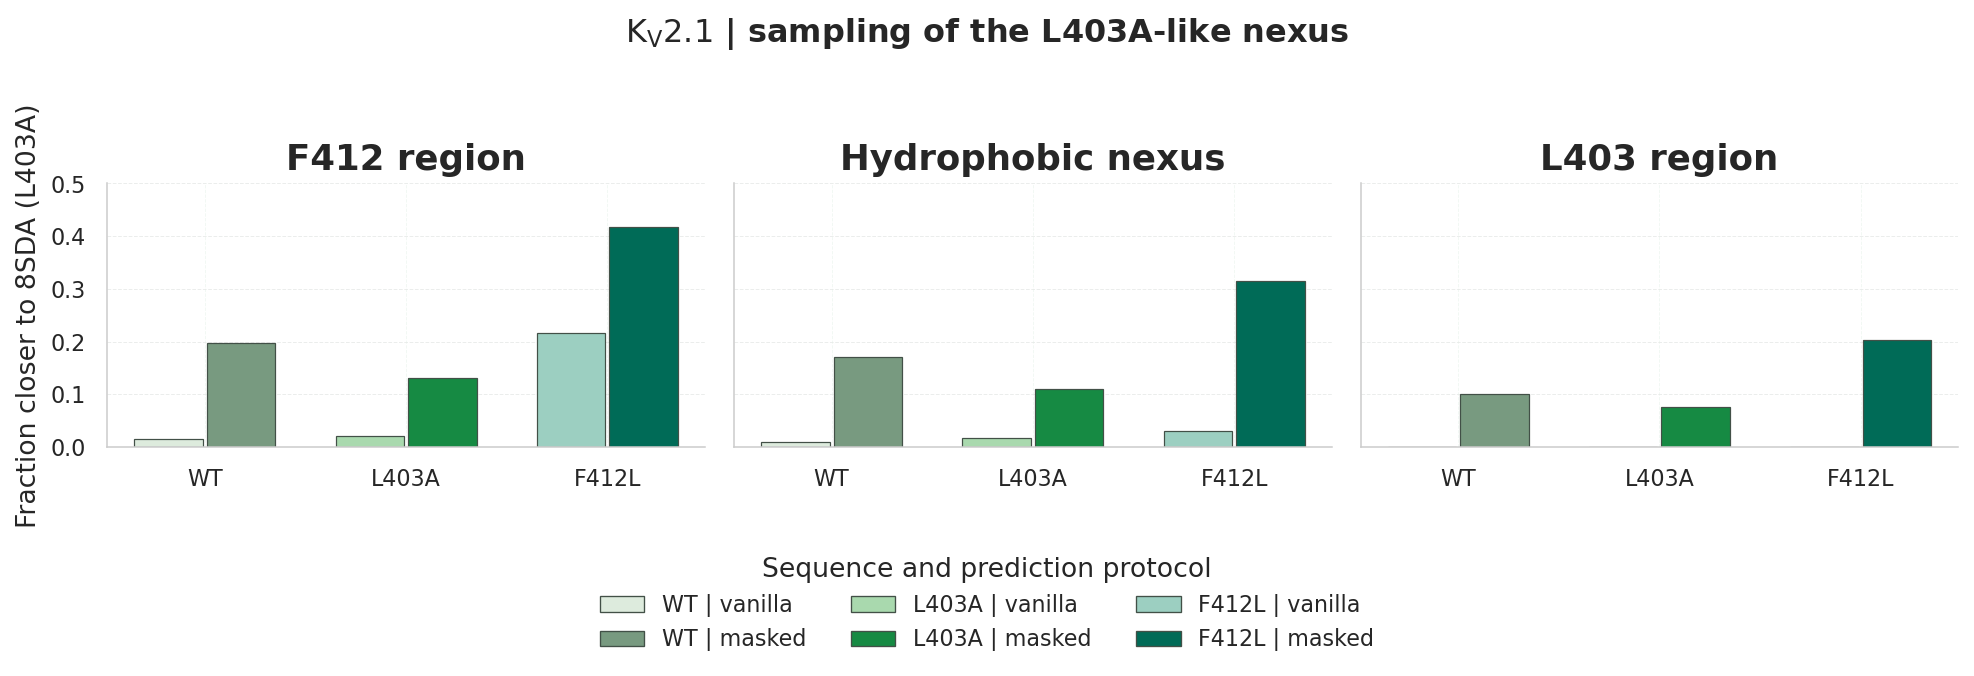

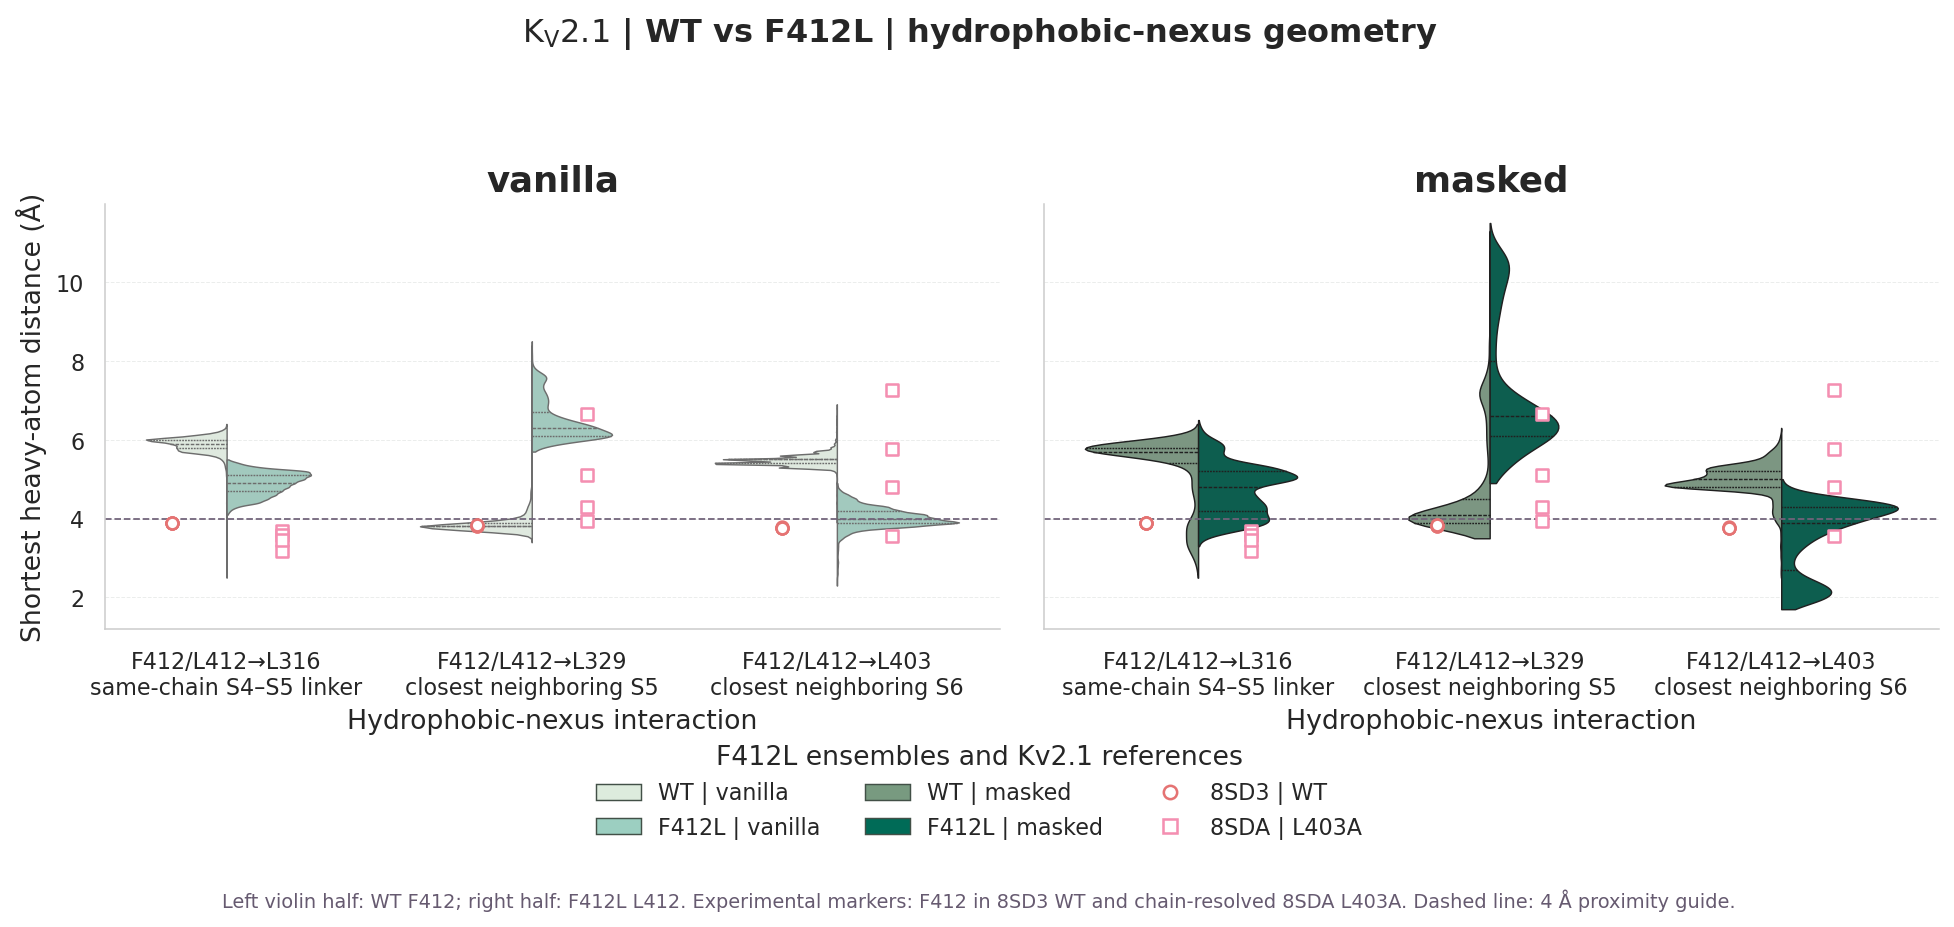

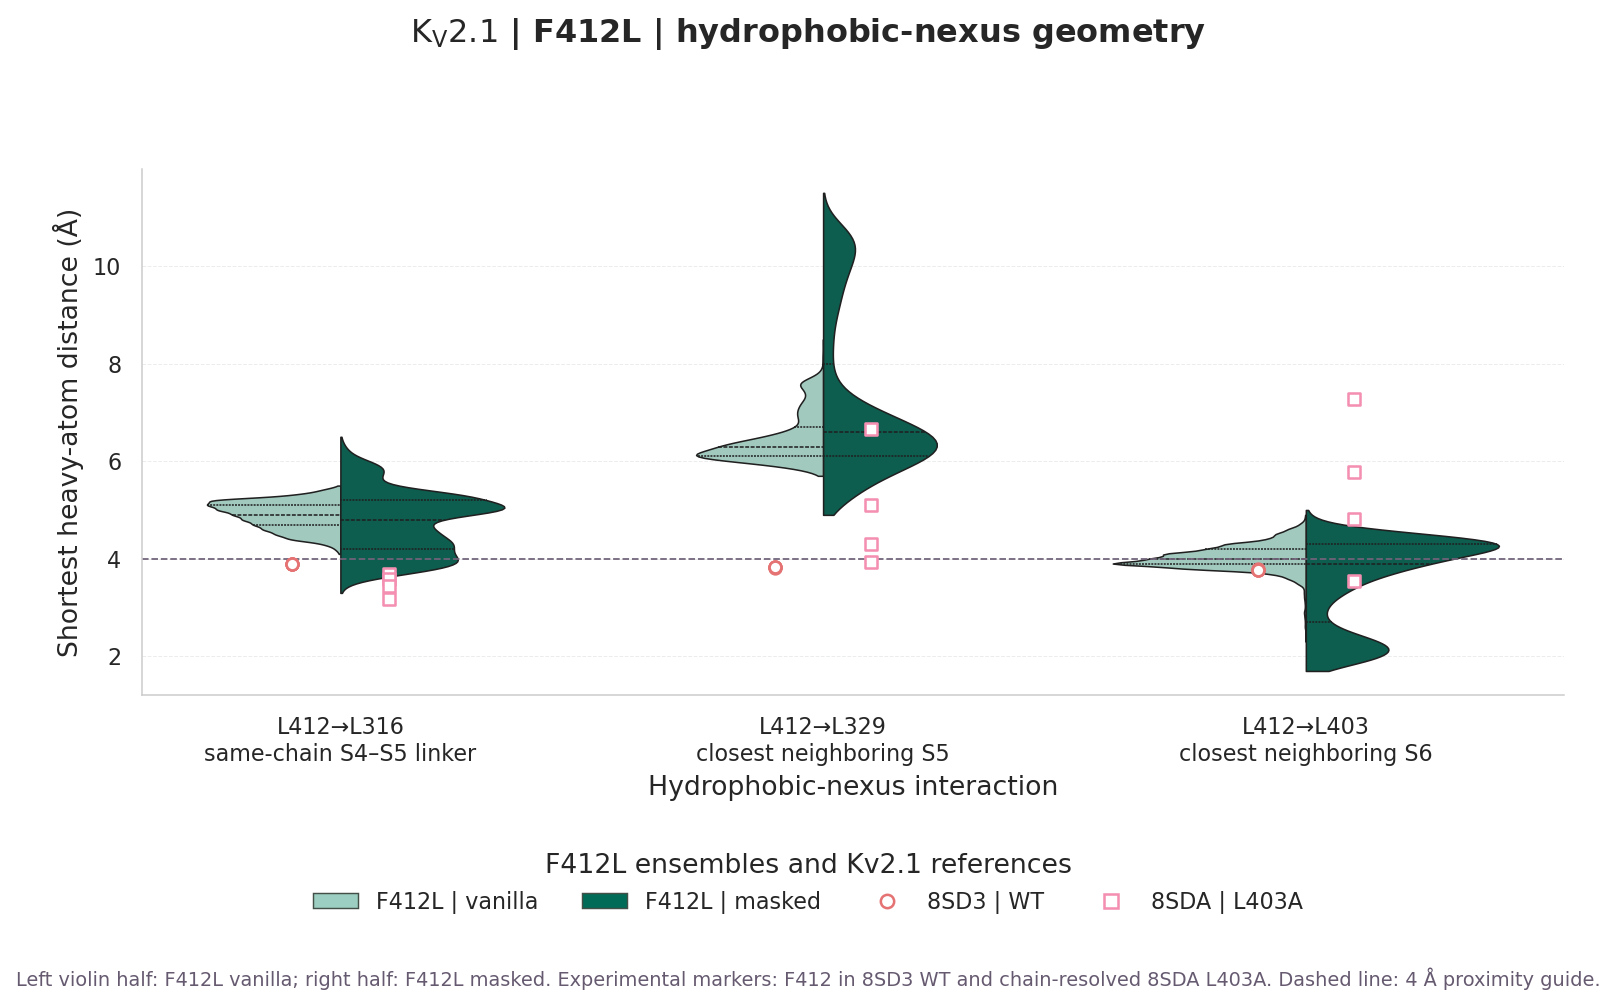

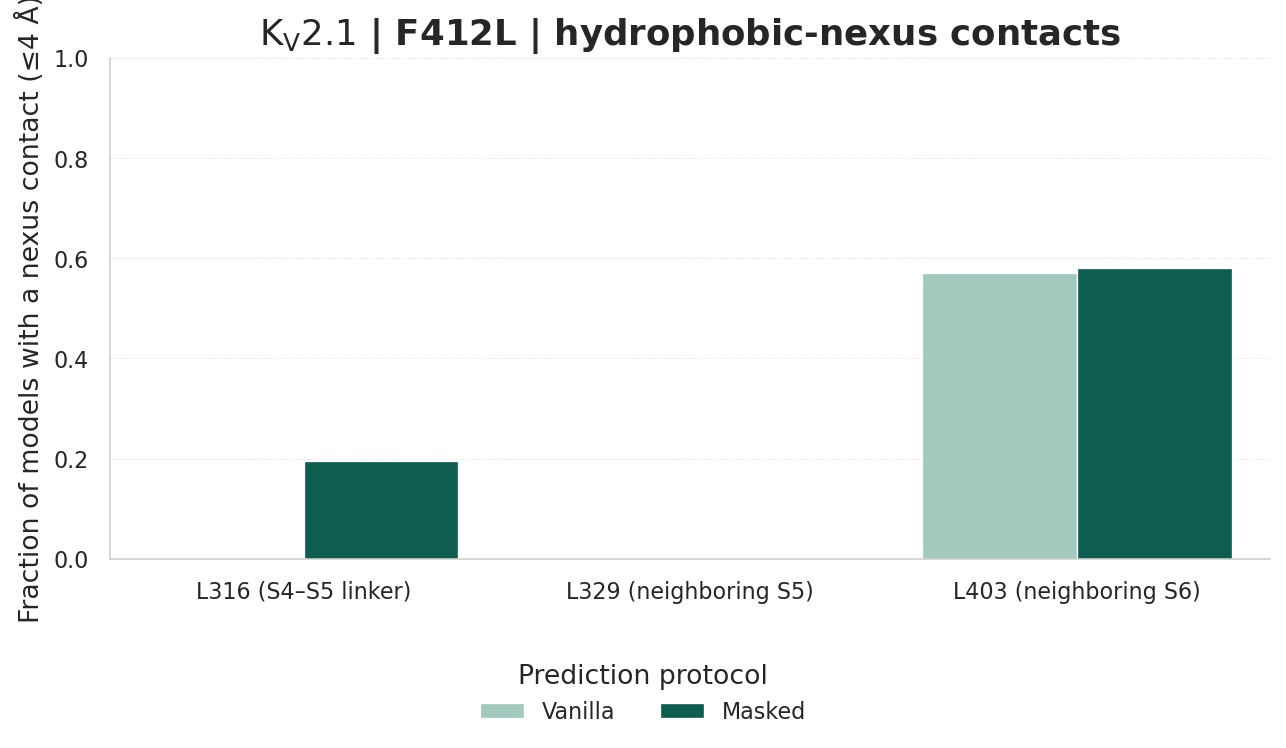

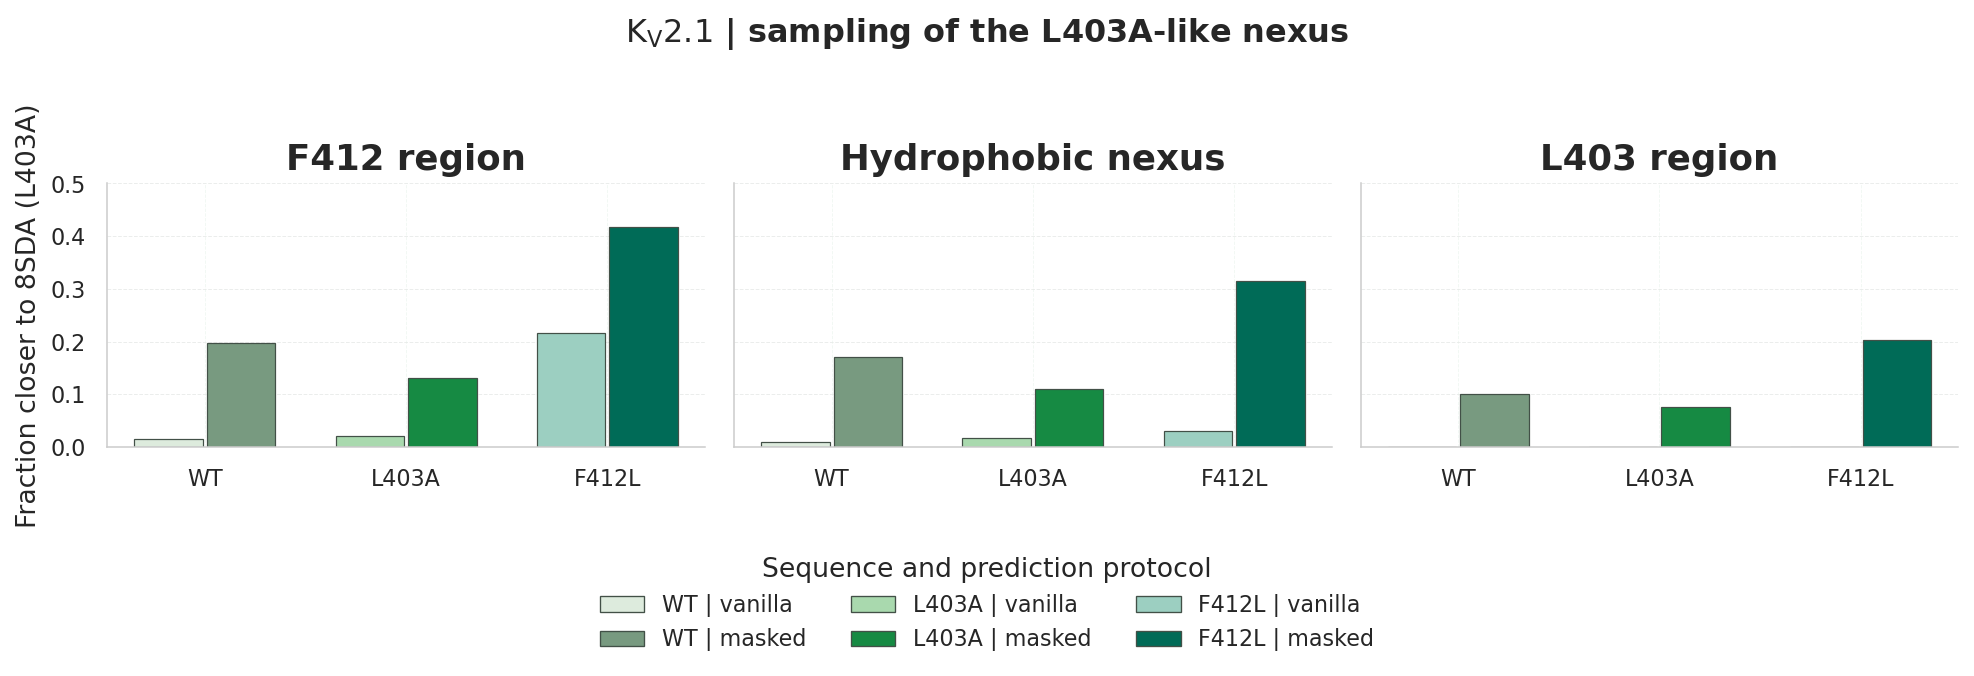

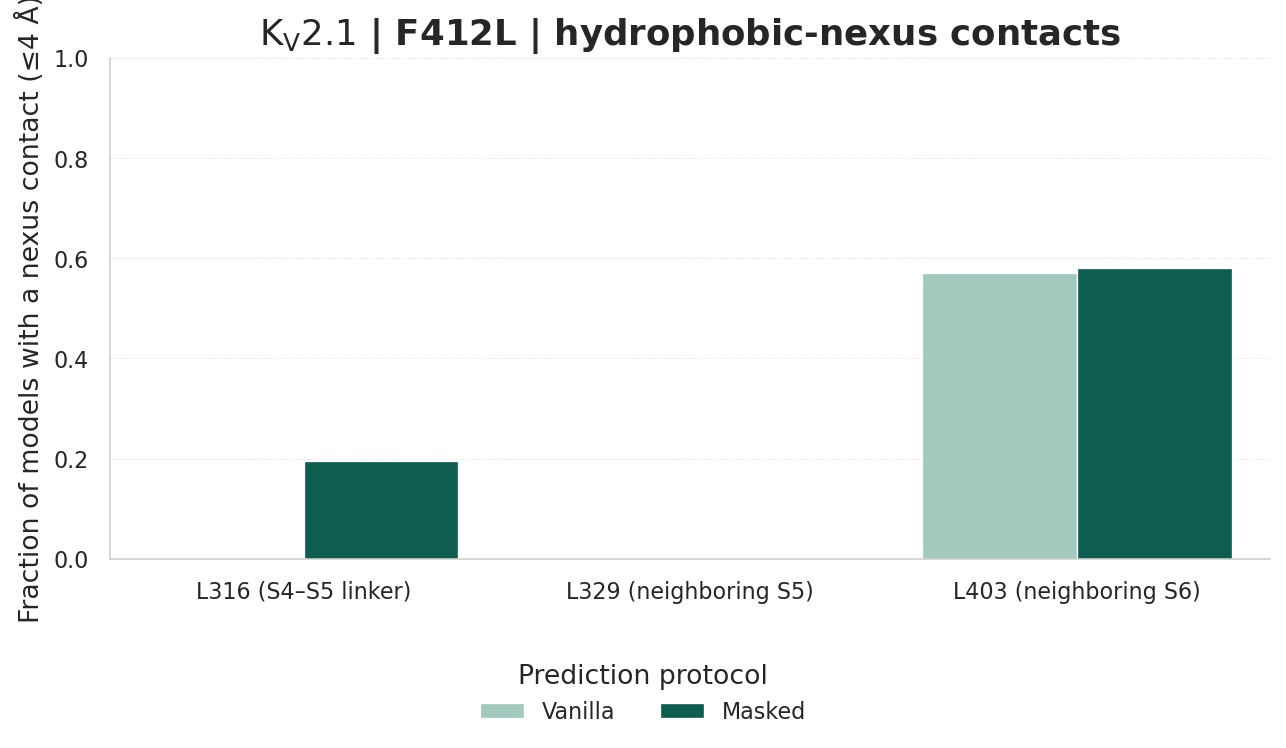

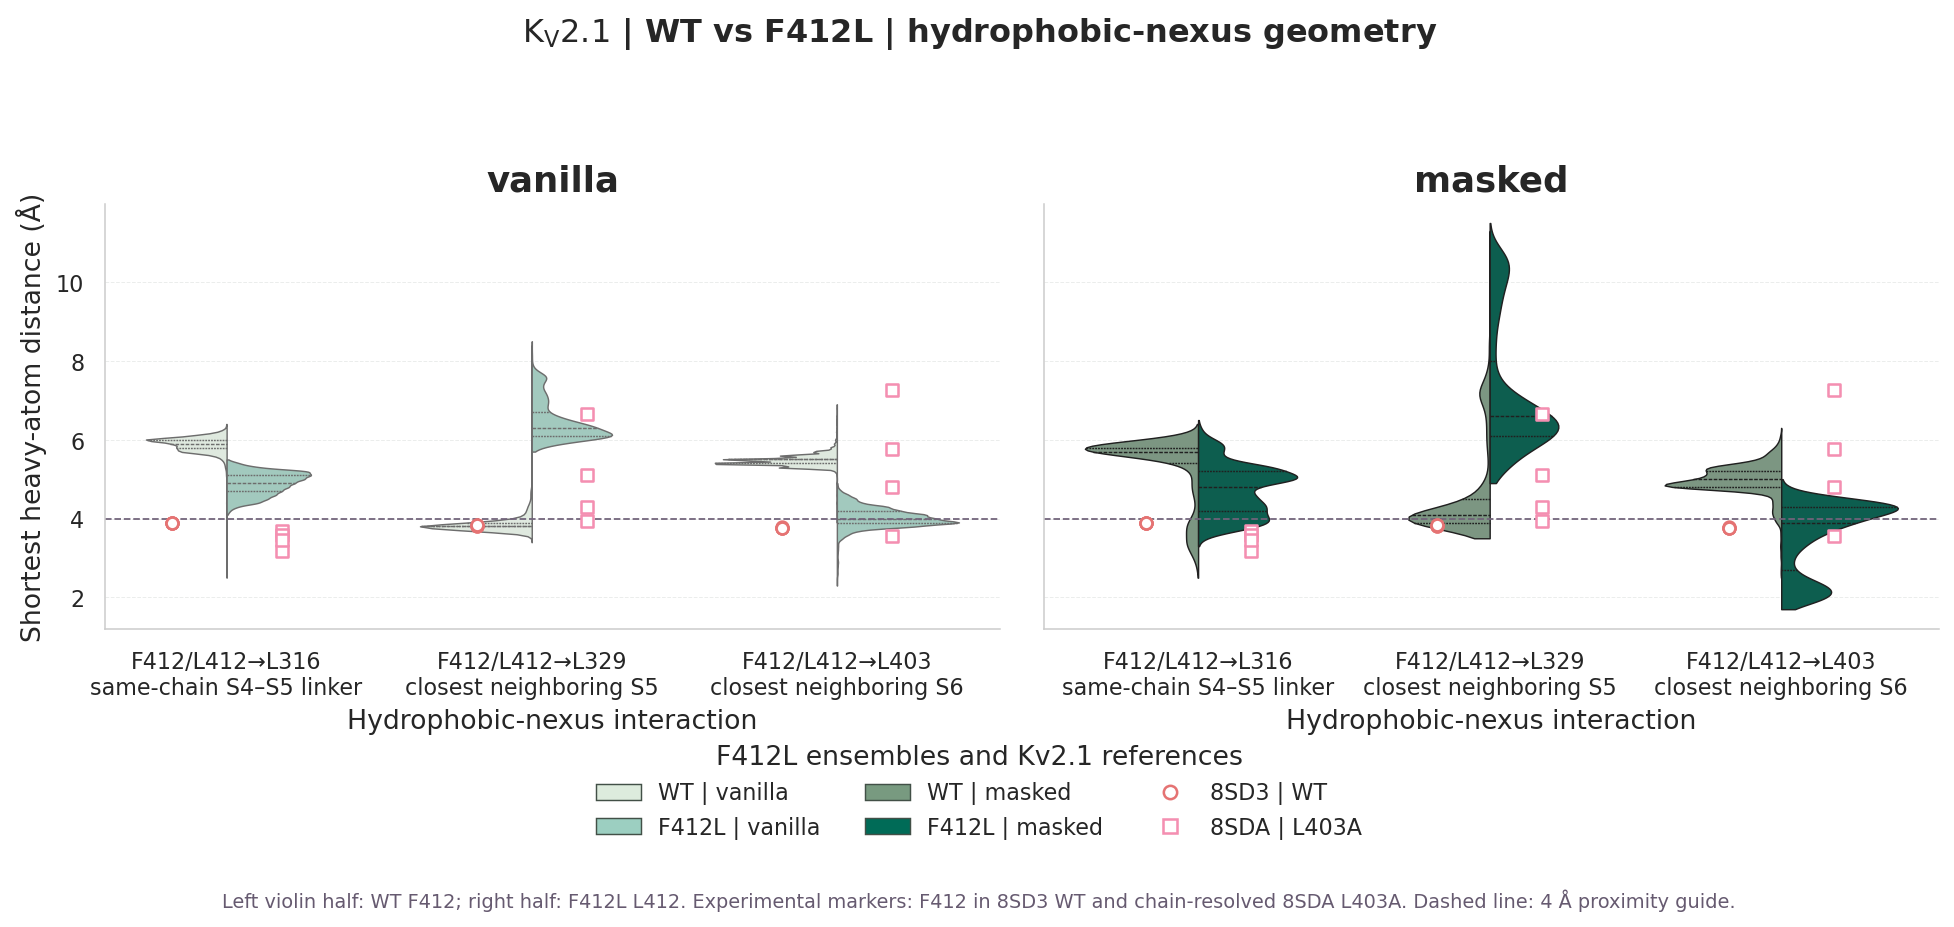

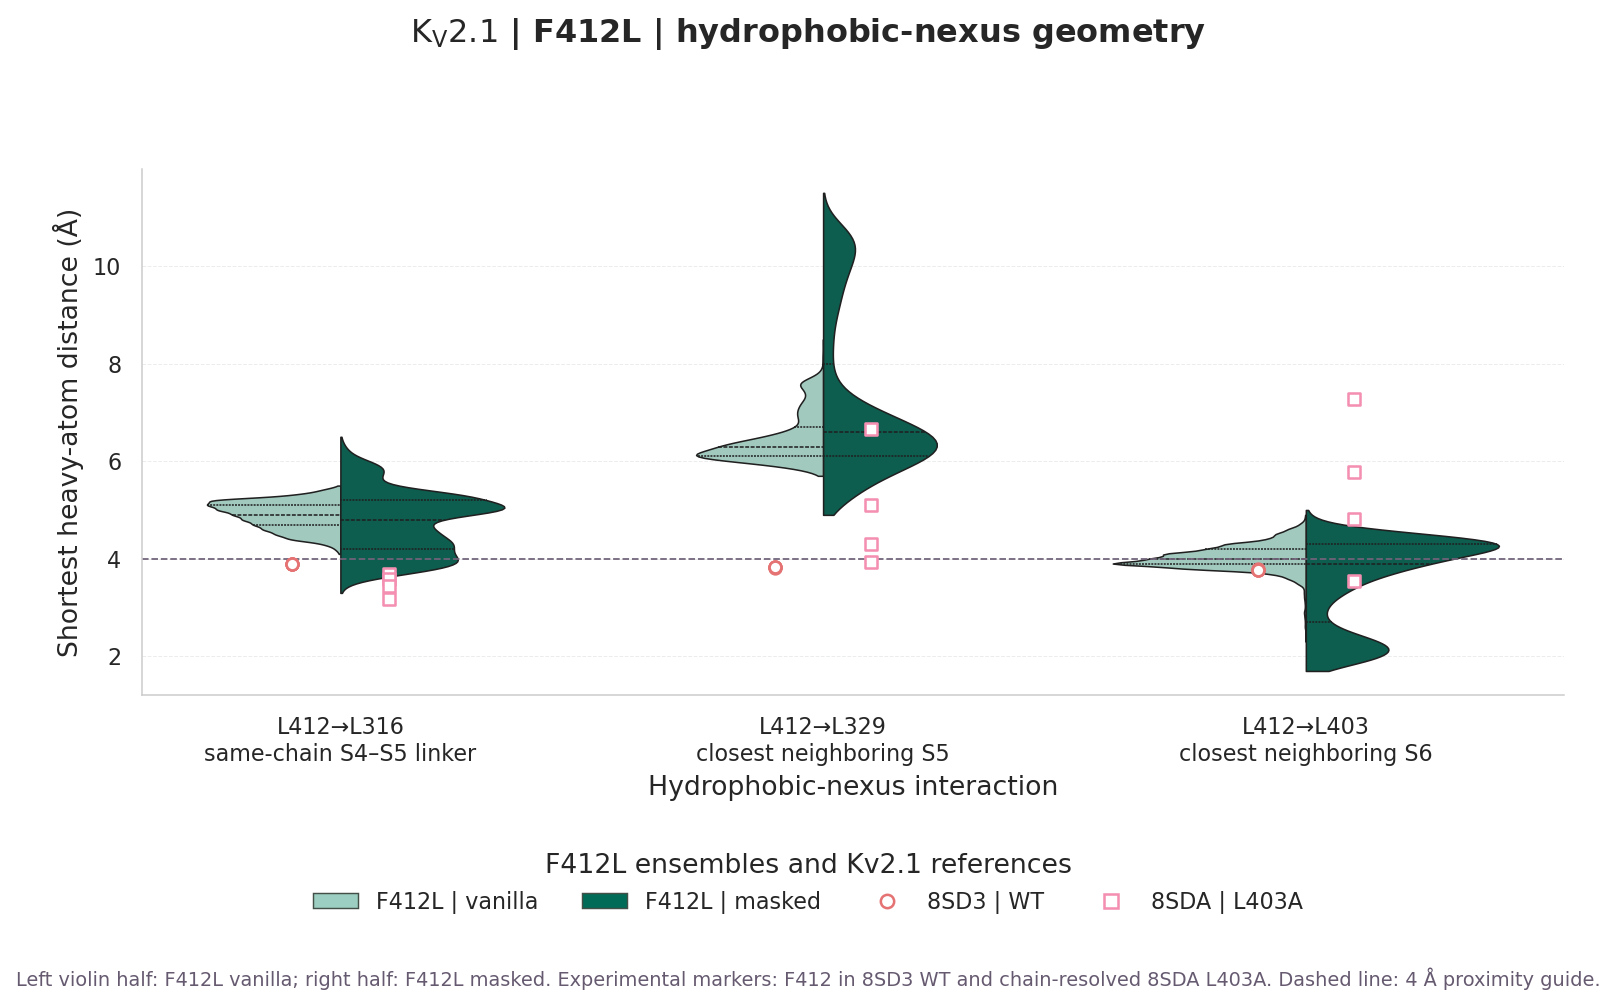

In [5]:
import importlib
import shared.rmsd_analysis as shared_rmsd_analysis
importlib.reload(shared_rmsd_analysis)
import shared.kv21_nexus_analysis as kv21_nexus_analysis
importlib.reload(kv21_nexus_analysis)
write_nexus_outputs = kv21_nexus_analysis.write_nexus_outputs

nexus = write_nexus_outputs(repo_root)
display(nexus["preference"].round(3))
display(nexus["contacts"].round(3))
display(nexus["experimental"].round(3))
display(nexus["representatives"].groupby(["sequence_condition", "protocol"]).head(1).round(3))
display(nexus["preference_figure"])
display(nexus["geometry_figure"])
display(nexus["mutant_geometry_figure"])
display(nexus["contact_figure"])